# Tester_branch에서 성능 확인 진행

In [ ]:
# 라이브러리 및 데이터 불러오기
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

df = pd.DataFrame(data = wine.data, columns = wine.feature_names)
df["target"] = wine.target

X = df.drop("target", axis = 1)
y = df["target"]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 42)

# DT 모델링 성능

---
- **A_brach에서 이루어질 작업**

Best Hyper-Parameter {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Score 0.9224137931034484


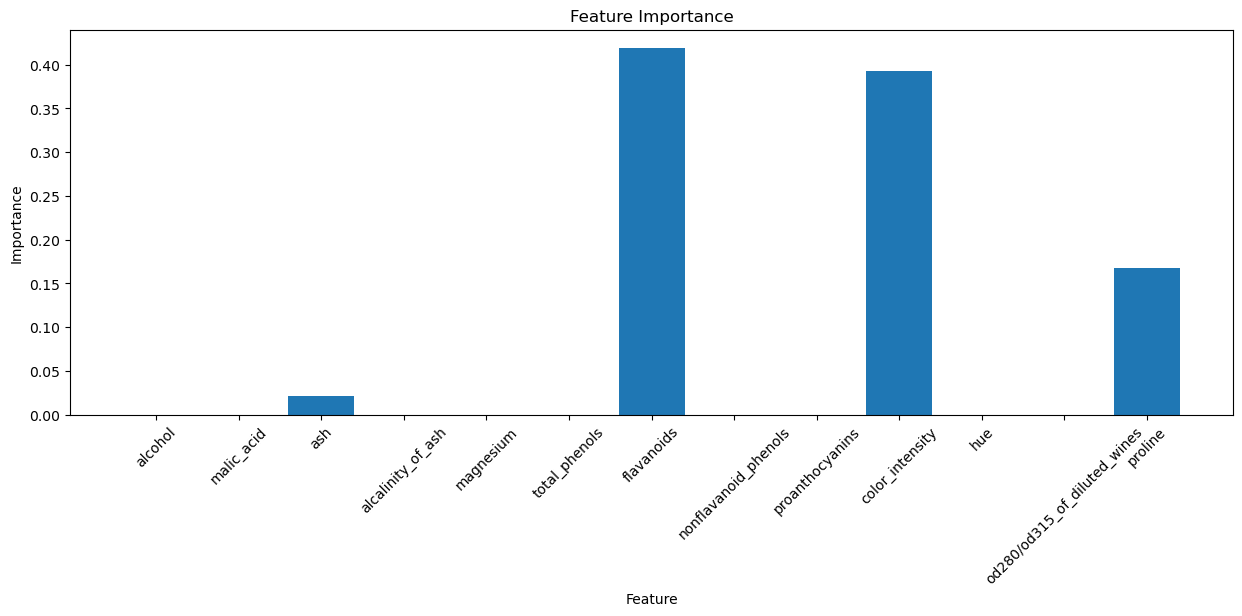

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 정의 및 하이퍼파라미터 튜닝
parameter_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 2, 4]
}

# HyperParameter Tuning 및 Fitting
dt_model = DecisionTreeClassifier(random_state = 42)

# 핵심 (cv = 5 : 전체 데이터셋을 5개로 분리하고 train test를 4개와 1개로 분류)
grid_search = GridSearchCV(dt_model, parameter_grid, cv = 5)

# HyperParameter를 찾고, 이를 통해 Fitting을 모두 수행
grid_search.fit(train_X, train_y)

print("Best Hyper-Parameter", grid_search.best_params_)
print("Best Score", grid_search.best_score_)


# 최적화된 하이퍼 파라미터를 DT 모델에 적용
best_model = grid_search.best_estimator_
pred_y_grid = best_model.predict(test_X)
accuracy_grid = accuracy_score(test_y, pred_y_grid)

# Feature Importance 시각화
importances = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(15, 5))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

---
- **B_branch에서 작업을 하는 동안 Admin_branch에서 이루어질 작업**

Best Hyper-Parameter {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score 0.9224137931034484


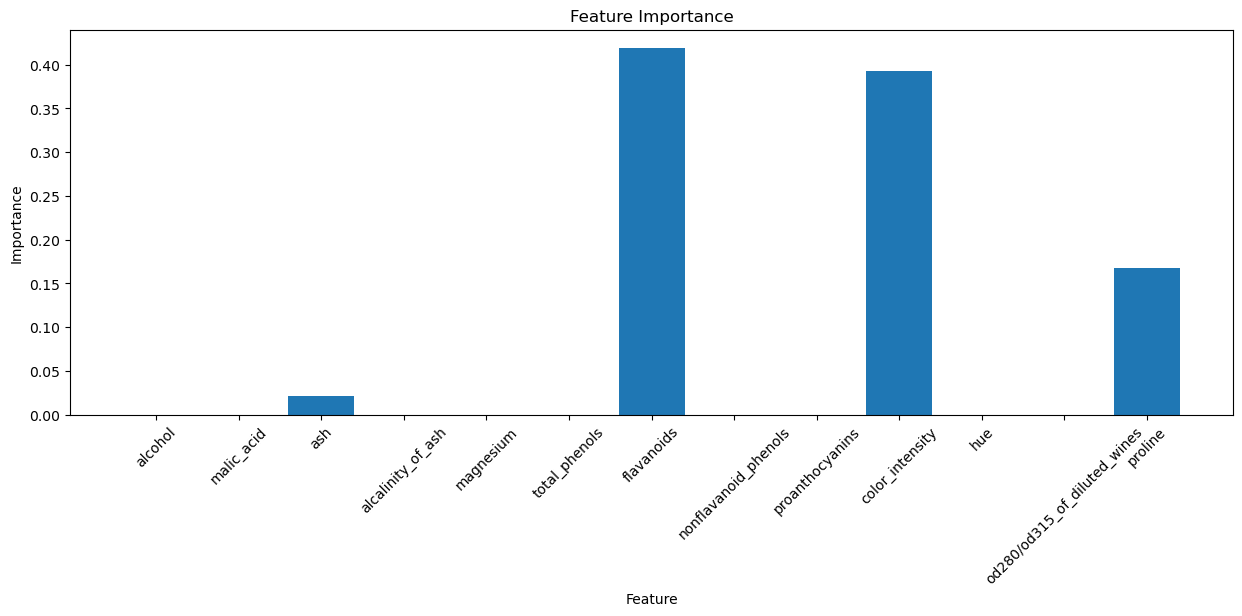

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 정의 및 하이퍼파라미터 튜닝
parameter_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# HyperParameter Tuning 및 Fitting
dt_model = DecisionTreeClassifier(random_state = 42)

# 핵심 (cv = 5 : 전체 데이터셋을 5개로 분리하고 train test를 4개와 1개로 분류)
grid_search = GridSearchCV(dt_model, parameter_grid, cv = 5)

# HyperParameter를 찾고, 이를 통해 Fitting을 모두 수행
grid_search.fit(train_X, train_y)

print("Best Hyper-Parameter", grid_search.best_params_)
print("Best Score", grid_search.best_score_)


# 최적화된 하이퍼 파라미터를 DT 모델에 적용
best_model = grid_search.best_estimator_
pred_y_grid = best_model.predict(test_X)
accuracy_grid = accuracy_score(test_y, pred_y_grid)

# Feature Importance 시각화
importances = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(15, 5))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# XGB 모델링 성능

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9576354679802955


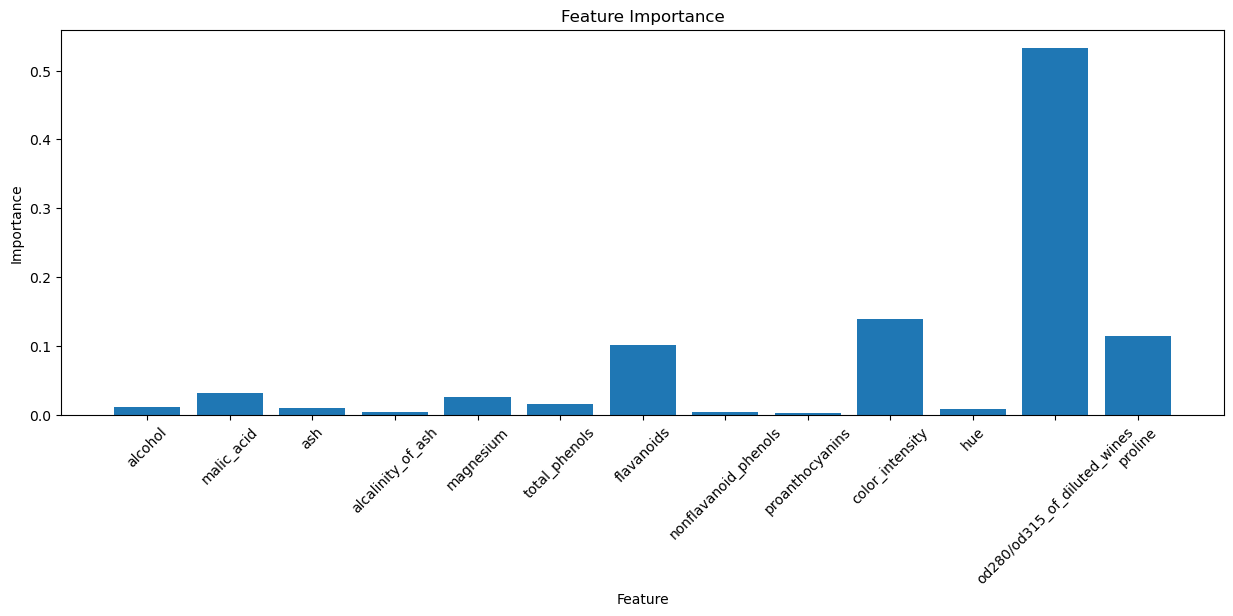

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 파라미터 튜닝
parameters = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators" : [50, 100, 200, 300]
    }

# HyperParameter Tuning 및 Fitting
xgb_model = XGBClassifier(random_state = 42)

# 핵심 (cv = 5 : 전체 데이터셋을 5개로 분리하고 train test를 4개와 1개로 분류)
xgb_grid_search = GridSearchCV(estimator = xgb_model, param_grid = parameters, cv = 5, scoring = "accuracy", n_jobs = -1)

# HyperParameter를 찾고, 이를 통해 Fitting을 모두 수행
xgb_grid_search.fit(train_X, train_y)

print("Best Parameters:", xgb_grid_search.best_params_)
print("Best accuracy:", xgb_grid_search.best_score_ )


# 최적화된 하이퍼 파라미터를 XGB 모델에 적용
best_xgb = xgb_grid_search.best_estimator_
xgb_pred = best_xgb.predict(test_X)
xgb_acc = accuracy_score(test_y, xgb_pred)


# Feature Importance 시각화
importances = best_xgb.feature_importances_
features = X.columns

plt.figure(figsize=(15, 5))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



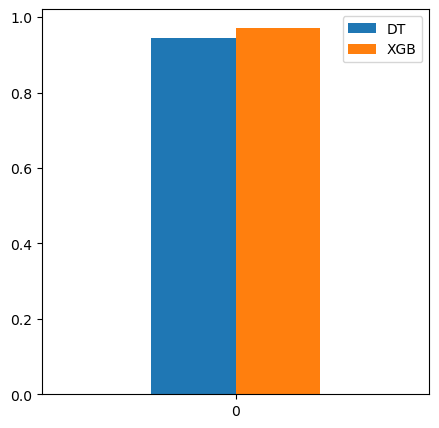

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# DT 성능 확인
print("="*20, "DT 성능 확인", "="*20)
print(f"DT accuracy : {accuracy_grid}")
print(classification_report(test_y, pred_y_grid))

# XGB 성능 확인
print("="*20, "XGB 성능 확인", "="*20)
print(f"XGB accuracy : {xgb_acc}")
print(classification_report(test_y, xgb_pred))


# 시각화
models = ["DT", "XGB"]
accuracies = [accuracy_grid, xgb_acc]

# 위치 설정
x = np.arange(1)
width = 0.35

fig, ax = plt.subplots(figsize=(5, 5))

# 바차트
bar1 = ax.bar(x - width/2, [accuracy_grid], width, label="DT")
bar2 = ax.bar(x + width/2, [xgb_acc], width, label="XGB")

# x축 설정
ax.set_xticks(x)
ax.set_xlim(-0.8, 0.8)

# 범례
ax.legend()

plt.show()